## Table of Contents
* [Convolutions](#convolutions)
* [Pooling](#pooling)
* [OneByOne Convolution](#one_by_one_convolutions)
* [Depthwise separable convolution](#depthwise_convolution)
* [Inverted residual block](#inverted_residual_block)
* [MobileNetV2](#mobilenetv2)
* [Transposed Convolutions](#transposed_convolutions)
* [Bilinear Interpolation](#bilinear_interpolation)


### Convolutions <a id="convolutions"></a>
Convolution is a mathematical operation that combines two functions to produce a third function. In the context of computer vision, the convolution operation involves sliding a filter (also known as a kernel) over an image to produce a feature map.

**Key components:**
1. Image (Input Matrix):
    - A 2D array (or matrix) of pixel values representing the input image. For a grayscale image, it's a single matrix. For a color image, it's a 3D matrix with depth corresponding to the color channels (RGB).
2. Kernel (Filter):
    - A smaller 2D matrix of weights (e.g., 3x3, 5x5) that is used to scan the image. The filter's purpose is to detect specific features such as edges, textures, or patterns.
3. Feature Map (Output Matrix):
    - The result of the convolution operation, which highlights the presence of specific features in the input image.

**Convolution Process:**
1. Sliding the Filter:
    - The filter is moved across the image in a sliding window fashion, starting from the top-left corner to the bottom-right corner.
2. Element-wise Multiplication:
    - For each position of the filter on the image, element-wise multiplication is performed between the filter and the corresponding image patch.
3. Summation:
    - The results of the element-wise multiplication are summed up to produce a single value, which is placed in the corresponding position of the feature map.
4. Stride and Padding:
    - Stride: Determines how much the filter moves at each step. A stride of 1 means the filter moves one pixel at a time. A larger stride results in a smaller feature map.
    - Padding: Adds a border of zeros around the image to control the size of the feature map. Without padding, the feature map becomes smaller than the input image. Padding helps preserve the spatial dimensions.

#### Example
Consider a 3x3 filter and a 5x5 image:

Filter: 

1  0  -1<br/>
1  0  -1<br/>
1  0  -1<br/>

Image:

3  4  1  2  5 <br/>
5  6  2  1  3 <br/>
1  2  3  4  6 <br/>
6  7  5  4  2 <br/>
3  2  1  6  5 <br/>

Place the filter on the top-left corner of the image.Perform element-wise multiplication and sum the results:

(3x1 + 4x0 + 1x(-1)) + (5x1 + 6x0 + 2x(-1)) + (1x1 + 2x0 + 3x(-1)) <br/>
= 3 + 0 - 1 + 5 + 0 - 2 + 1 + 0 - 3 <br/>
= 3 - 1 + 5 - 2 + 1 - 3 <br/>
= 3 <br/>

Move the filter to the right by one pixel (stride = 1) and repeat the process until the entire image is covered.

### **Formula to Calculate Output Dimensions**

For either spatial dimension, the output size of a convolution is

$$
\text{out}=\left\lfloor
\frac{\text{in}+2p-d(k-1)-1}{s}+1
\right\rfloor,
$$

where $k$ is kernel size, $s$ stride, $p$ padding, and $d$ dilation.

#### Simplified formula when dilation is 1

Many introductory explanations assume an undilated kernel, so $d=1$. In that case the kernel's effective size is

$$
d(k-1)+1 = 1(k-1)+1 = k.
$$

Substituting $d=1$ into the general formula gives

$$
\text{out}=\left\lfloor\frac{\text{in}+2p-k}{s}+1\right\rfloor.
$$

For a square input of size $n\times n$ and a square kernel of size $f\times f$, this is often written as

$$
O=\left\lfloor\frac{n-f+2p}{s}+1\right\rfloor.
$$

**Example:**
If you have an input image of size $32 \times 32$, a filter of size $5 \times 5$, stride $1$, and padding $2$, then:

$$
O = \frac{(32 - 5 + 2 \times 2)}{1} + 1 = \frac{(32 - 5 + 4)}{1} + 1 = \frac{31}{1} + 1 = 32
$$

- **Stride** controls how far the kernel moves.
- **Padding** supplies values outside the original boundary (usually zeros).
- **Dilation** spaces kernel elements apart, increasing coverage without adding weights.
- “Valid” usually means no padding. “Same” aims to preserve spatial size for stride 1; exact conventions can vary when stride is greater than 1 or the kernel is even.


### **Valid vs. Same Convolutions**

1. **Valid Convolution:**
   - In a **valid** convolution, no padding is applied to the input image. This means the filter only slides within the input dimensions, without extending beyond the edges.
   - In this case, $p = 0$.
   - Output size decreases after applying the convolution, depending on the filter size and stride.
   
   Formula for output size in valid convolution:
   $$
   O = \frac{n - f}{s} + 1
   $$

   Example: If $n = 32$, $f = 5$, $s = 1$, and $p = 0$ (valid convolution), then:
   $$
   O = \frac{(32 - 5)}{1} + 1 = 28
   $$
   The output size is $28 \times 28$.

2. **Same Convolution:**
   - In a **same** convolution, the goal is to preserve the input size after convolution. This is done by adding padding around the input image so that the output dimensions are the same as the input.
   - Padding $p$ is typically calculated to achieve this.
   - For a stride $s = 1$, the padding is:
     $$
     p = \frac{f - 1}{2}
     $$
   - In this case, the output dimensions will be the same as the input.

   Example: If $n = 32$, $f = 5$, and $s = 1$, for a **same** convolution:
   $$
   p = \frac{5 - 1}{2} = 2
   $$
   Applying this padding will give you the same output size as the input, $32 \times 32$.

   ---

### Pooling <a id="pooling"></a>

In Convolutional Neural Networks (CNNs), **pooling** is an operation used to reduce the spatial dimensions (height and width) of the input feature map while retaining important information. Pooling helps in making the network computationally efficient, reduces the chances of overfitting, and provides spatial invariance.

### Types of Pooling:

1. **Max Pooling**: 
   - It selects the maximum value from the region of the input that the filter covers.
   - It captures the most prominent feature in a specific region.

2. **Average Pooling**: 
   - It calculates the average of all values in the region that the filter covers.
   - It smoothens the feature map, giving an average representation.

### Pooling Operation:

In a pooling operation, a filter (or pooling window) of size $f \times f$ slides over the input feature map, aggregating values within that region based on the type of pooling (max or average). The filter is applied with a stride $s$ (step size), similar to convolution operations, and optionally padding $p$ can be used.

### Output dimensions

For each spatial dimension, pooling produces an output size of

$$
\text{out}=\left\lfloor\frac{\text{in}+2p-d(k-1)-1}{s}+1\right\rfloor,
$$

where $k$ is the pooling-window size, $s$ is the stride, $p$ is the padding, and $d$ is the dilation (usually $1$ for pooling). Apply the formula separately to height and width when these values differ.

With no padding and no dilation, this simplifies to

$$
\text{out}=\left\lfloor\frac{\text{in}-k}{s}+1\right\rfloor.
$$

**Example:** A $32 \times 32$ feature map pooled with a $2 \times 2$ window, stride $2$, and no padding has spatial output size

$$
\left\lfloor\frac{32-2}{2}+1\right\rfloor=16,
$$

so the pooled feature map is $16 \times 16$. Pooling changes spatial dimensions but leaves the number of channels unchanged.

---

<a id="dilation"></a>
### Dilation: spreading out the kernel

**Dilation controls the spacing between elements inside a kernel.** It lets the same number of kernel weights examine a larger region of the input.

Consider a one-dimensional three-weight kernel `[a, b, c]`. With ordinary dilation $d=1$, it samples adjacent input values:

```text
input:       x0  x1  x2  x3  x4
              ↑   ↑   ↑
dilation 1:  a   b   c
```

The first output is $a x_0 + b x_1 + c x_2$. With dilation $d=2$, successive weights are two input positions apart:

```text
input:       x0  x1  x2  x3  x4
              ↑       ↑       ↑
dilation 2:  a       b       c
```

Now the first output is $a x_0 + b x_2 + c x_4$. The kernel still has only three learned weights; it simply samples them across a wider area. The positions between the arrows are skipped for this placement—they are not extra zero-valued weights. Later placements can still sample those positions.

For a two-dimensional $3\times3$ kernel, the sampled positions look like this:

```text
dilation 1          dilation 2
x x x               x . x . x
x x x               . . . . .
x x x               x . x . x
                    . . . . .
                    x . x . x
```

Both kernels contain nine weights, but dilation 2 makes the $3\times3$ kernel cover the area of a $5\times5$ kernel. This covered width or height is the **effective kernel size**:

$$
k_{\text{effective}} = d(k-1)+1.
$$

For example, $k=3$ and $d=2$ gives $k_{\text{effective}}=2(3-1)+1=5$. Increasing dilation therefore expands the kernel's receptive field without adding parameters. This is useful when a model needs wider context while retaining spatial resolution.

Dilation and stride affect different things:

- **Dilation** spaces out the elements *within* one kernel placement.
- **Stride** determines how far the *whole kernel* moves before producing the next output.

Because dilation enlarges the effective kernel, it can reduce the output size unless padding is increased. In the example above, a $3\times3$ kernel with dilation 2 behaves geometrically like a $5\times5$ kernel. Padding 2 with stride 1 therefore preserves a $32\times32$ input as a $32\times32$ output.

#### Why dilation is useful

Early CNN layers commonly detect small local patterns such as edges and corners. Deeper layers often need wider context—for example, determining that features separated across an image belong to the same object. Dilation gives each output value access to a wider region of the input, expanding the **receptive field** without:

- increasing the kernel's number of learned parameters,
- applying pooling, or
- using a larger stride that would reduce the feature map's spatial resolution.

This makes dilated convolution especially useful for **semantic segmentation**, a dense prediction task that assigns a class to every pixel. A pixel or small patch is often ambiguous—a wheel-like patch, for example, could belong to a car, bicycle, or motorcycle. A wider receptive field supplies context from the surrounding object and scene, helping the model determine what the pixel belongs to and how far the object extends. Dilation provides this broader view without the spatial downsampling caused by pooling or a larger stride, so the feature map can retain the fine detail needed for accurate object boundaries.

> Dilation spreads the same kernel weights over a wider input area. It increases what the kernel can see, not how many weights it learns.
---

<a id="channels-filters-and-parameter-counts"></a>
## Channels, filters, and parameter counts

A **channel** is one 2D map: an RGB image has three input channels; later layers contain learned feature maps.

In a standard convolution (`groups=1`), **one filter spans all input channels and produces one output channel**. A layer with eight filters therefore produces eight output channels.

### Example: RGB input, eight 3×3 filters

Each filter contains three 3×3 slices—one for red, green, and blue. It convolves each slice with its corresponding channel, sums the results, and adds one bias to produce a single feature map.

| Quantity | Shape or count |
|---|---|
| One filter | `(3, 3, 3)` = input channels × height × width |
| All eight filters (`conv.weight`) | `(8, 3, 3, 3)` = output channels × input channels × height × width |
| Weights per filter | $3 \times 3 \times 3 = 27$ |
| Total parameters, including biases | $8 \times (27 + 1) = \mathbf{224}$ |

“Kernel” and “filter” are often used interchangeably. Here, a **kernel slice** means one 2D slice of a filter; PyTorch's `kernel_size=3` specifies only its spatial size, 3×3.

For `nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1)`, the batch shape changes as follows:

```text
Input:  (4, 3, 32, 32)  →  Output: (4, 8, 32, 32)
         N  C   H   W               N  C   H   W
```

The eight filters determine the output channel count; stride 1 and padding 1 preserve the image height and width in this example.

### General parameter formula

For $C_{in}$ input channels, $C_{out}$ filters, and spatial kernel size $K_h \times K_w$:

$$
\text{Parameters} = C_{out}\left(C_{in}K_hK_w + 1\right).
$$

The $+1$ is one bias per filter; omit it when `bias=False`.

**Weight sharing:** each filter reuses the same weights at every image location. Larger images or batches require more computation, but do not add learned parameters.

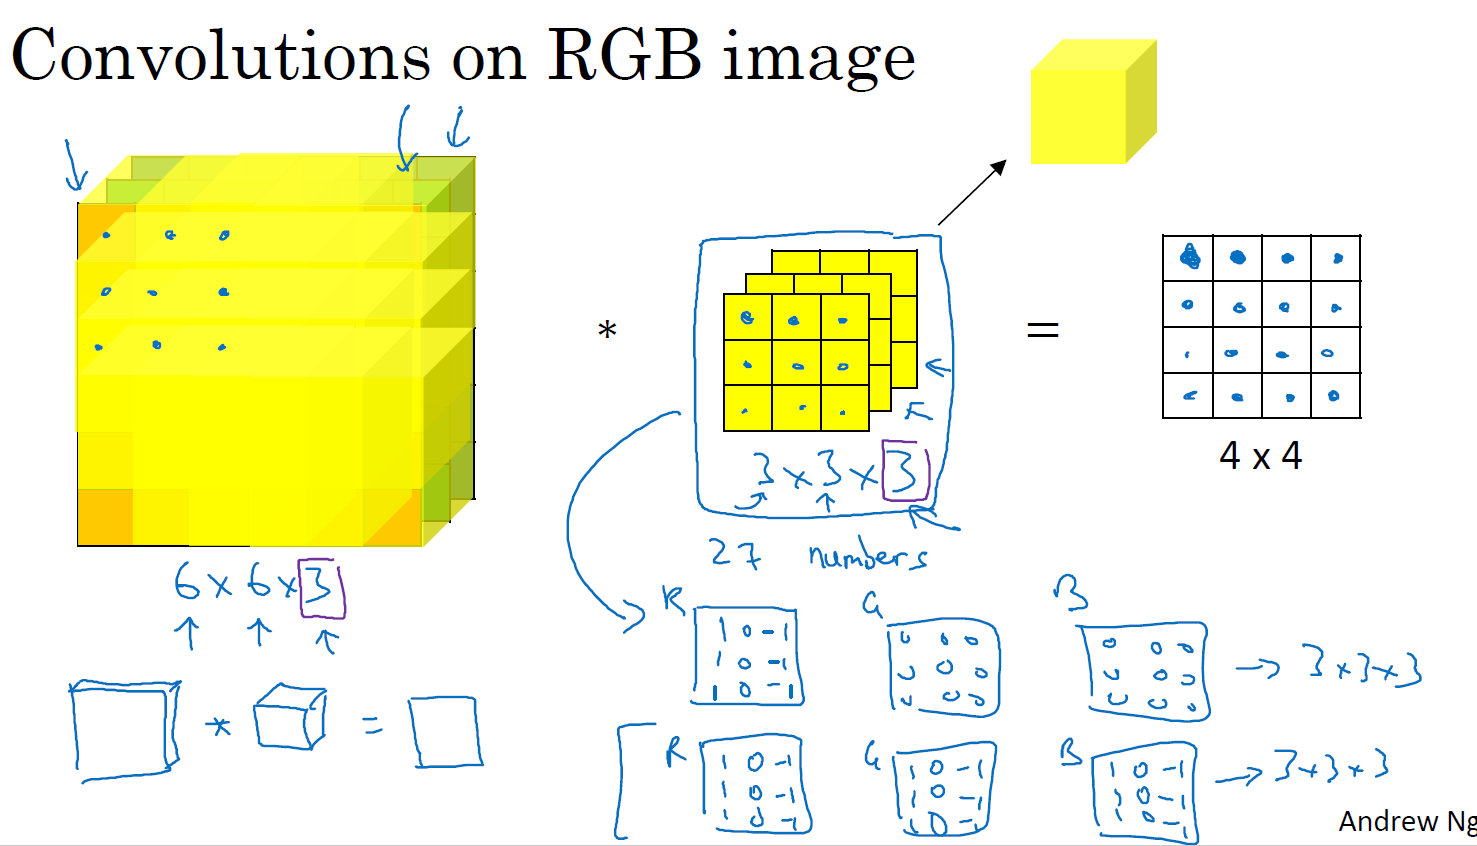

---


### 1x1 convolution <a id="one_by_one_convolutions"></a>

A 1x1 convolution is a special type of convolution operation where the filter size is 1x1. This means it doesn't consider the spatial relationships between pixels, but instead operates on a per-pixel basis across all channels of the input feature map.

How it Works
- The 1x1 filter slides over the input feature map, but since it's 1x1, it only covers a single pixel at a time.
- For each pixel, the filter multiplies its weights with the corresponding values in all channels of the input feature map and sums the results to produce a single output value. Given an input feature map of dimensions H x W x C_in (height, width, and number of input channels), and a filter of size    1 x 1 x C_in x C_out (1x1 spatial dimension, C_in input channels and C_out output channels), the output feature map will have dimensions H x W x C_out
- This process is repeated for all pixels in the input feature map, resulting in an output feature map with the same spatial dimensions but potentially a different number of channels.

**Use Cases: What a 1x1 Convolution Accomplishes**

1. **Dimensionality Reduction (Channel Compression):**
    - A 1x1 convolution can use fewer output channels than input channels. Suppose the input has 256 channels and the 1x1 convolution has 64 filters:

$$
28 \times 28 \times 256
\xrightarrow{\text{1x1 convolution, 64 filters}}
28 \times 28 \times 64
$$

The height and width stay the same, while the channel count is reduced from 256 to 64. This makes a later 3x3 convolution much cheaper. Suppose that convolution produces 128 output channels.

**Without channel reduction:**

$$
3 \times 3 \times 256 \times 128
= 294{,}912 \text{ weights}
$$

**With channel reduction:**

$$
\begin{aligned}
\text{1x1 convolution:} \quad &1 \times 1 \times 256 \times 64 = 16{,}384 \\
\text{3x3 convolution:} \quad &3 \times 3 \times 64 \times 128 = 73{,}728 \\
\text{Total:} \quad &16{,}384 + 73{,}728 = 90{,}112 \text{ weights}
\end{aligned}
$$


2. **Linear Projection (Learning New Channel Combinations):**
    - At a particular spatial location `(h, w)`, collect the input channel values into a vector $\mathbf{x}_{h,w}$ of length $C_{in}$. A 1x1 convolution computes $\mathbf{y}_{h,w} = W\mathbf{x}_{h,w} + \mathbf{b}$, where $W$ has shape $C_{out} \times C_{in}$. The same learned matrix is applied at every spatial location.
    - For example, consider four channel values at one spatial location and the weights of one 1x1 filter:

$$
\mathbf{x}_{h,w} =
\begin{bmatrix}2 \\ 3 \\ -1 \\ 4\end{bmatrix},
\qquad
\mathbf{w} =
\begin{bmatrix}0.5 \\ 1 \\ -2 \\ 0.25\end{bmatrix}
$$

The filter computes a dot product across the channels:

$$
\begin{aligned}
y_{h,w}
&= \mathbf{w}^{T}\mathbf{x}_{h,w} + b \\
&= (0.5 \times 2) + (1 \times 3) + (-2 \times -1) + (0.25 \times 4) + b \\
&= 1 + 3 + 2 + 1 + b \\
&= 7 + b
\end{aligned}
$$

One filter produces one output channel. If there are $C_{out}$ filters, the complete operation at every location is:

$$
\mathbf{y}_{h,w} = W\mathbf{x}_{h,w} + \mathbf{b},
\qquad W \in \mathbb{R}^{C_{out} \times C_{in}}
$$

Therefore:

- When $C_{out} < C_{in}$, the layer compresses the channels.
- When $C_{out} > C_{in}$, the layer expands the channels.
- When $C_{out} = C_{in}$, the layer can still learn a new mixture of the existing channels.

3. **Adding Non-Linearity:**
    - A 1x1 convolution by itself is a linear operation; it does not become nonlinear merely because $C_{out} = C_{in}$. However, following it with an activation such as ReLU creates a nonlinear transformation. Stacking multiple `1x1 convolution + activation` layers lets the network learn more complex relationships among the channels at each spatial location.

4. **Network-in-Network (NiN) Architecture:**
    - Network-in-Network uses small multilayer networks at every spatial location, commonly implemented as a spatial convolution followed by one or more 1x1 convolutions and nonlinear activations. Instead of producing a fixed linear combination of the local features, these layers learn a more expressive nonlinear transformation of the channel vector at each location.
    - A final 1x1 convolution can map the channels to one feature map per class. Global average pooling then averages each class feature map to produce the class scores. This can replace traditional fully connected classification layers while keeping the network fully convolutional.

5. **Inception Modules:**
    - Inception modules place 1x1 convolutions before larger 3x3 and 5x5 convolutions to reduce the number of input channels. The larger filters then operate on a smaller depth, substantially reducing their parameter count and computation.

6. **Bottleneck Layers in ResNet:**
    - A ResNet bottleneck block commonly uses a 1x1 convolution to reduce the channel count, a 3x3 convolution to process spatial information efficiently, and another 1x1 convolution to restore or expand the channel count. The 1x1 layers handle channel mixing, while the 3x3 layer handles spatial mixing.


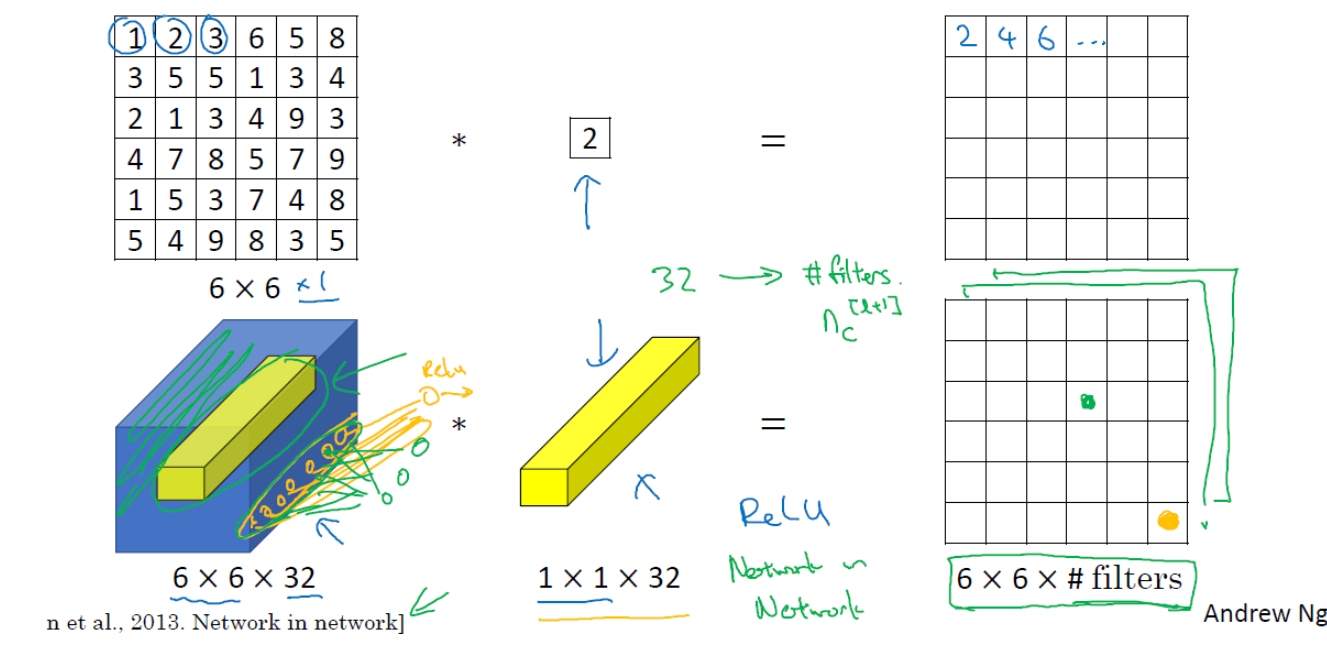

---
### **Depthwise Separable Convolution** <a id="depthwise_convolution"></a>

A standard convolution performs two jobs at the same time:

1. It finds **spatial patterns** by looking at neighboring positions with a $K \times K$ kernel.
2. It creates new features by **mixing information across all input channels**.

A depthwise separable convolution separates these jobs into two cheaper operations:

$$
\text{Depthwise convolution (spatial filtering)}
\quad \longrightarrow \quad
\text{Pointwise convolution (channel mixing)}
$$

This factorization substantially reduces the number of parameters and multiply-accumulate operations, which is why it is commonly used in efficient architectures such as MobileNet, Xception, EfficientNet, and ShuffleNet.

#### Standard Convolution

Suppose the input has shape $H \times W \times C_{in}$ and we want $C_{out}$ output channels. A standard convolution uses $C_{out}$ filters, and every filter spans **all** $C_{in}$ input channels:

$$
\text{Shape of one filter} = K \times K \times C_{in}
$$

$$
\text{Total number of weights}
= K^2 C_{in} C_{out}
$$

Each output value therefore combines information from both the local $K \times K$ spatial region and every input channel in a single operation. The output shape is $H' \times W' \times C_{out}$, where $H'$ and $W'$ depend on the padding and stride.

#### Depthwise Separable Convolution

##### Step 1: Depthwise Convolution — Learn Spatial Features

Instead of one filter spanning every channel, assign one $K \times K$ filter to each input channel. Each channel is processed independently:

$$
H \times W \times C_{in}
\xrightarrow{\text{depthwise } K \times K}
H' \times W' \times C_{in}
$$

$$
\text{Depthwise weights}
= K^2 C_{in}
$$

For example, a depthwise filter assigned to the red channel processes only the red channel; it never sees the green or blue channels. Thus, this step learns spatial patterns but does **not** mix information between channels. In PyTorch, this operation is implemented with `groups=C_in`.

##### Step 2: Pointwise Convolution — Mix the Channels

Next, apply $C_{out}$ filters of size $1 \times 1 \times C_{in}$. Each filter sees all the channel values at one spatial location and learns a different weighted combination of them:

$$
H' \times W' \times C_{in}
\xrightarrow{\text{pointwise } 1 \times 1}
H' \times W' \times C_{out}
$$

$$
\text{Pointwise weights}
= C_{in} C_{out}
$$

The complete depthwise separable convolution therefore has:

$$
\text{Total weights}
= K^2 C_{in} + C_{in} C_{out}
$$

#### Numerical Example

Consider a $3 \times 3$ convolution that maps an input with 256 channels to an output with 128 channels. Bias parameters are omitted for simplicity.

**Standard convolution:**

$$
\begin{aligned}
\text{Weights}
&= 3 \times 3 \times 256 \times 128 \\
&= 294{,}912
\end{aligned}
$$

**Depthwise separable convolution:**

$$
\begin{aligned}
\text{Depthwise weights}
&= 3 \times 3 \times 256 = 2{,}304 \\
\text{Pointwise weights}
&= 1 \times 1 \times 256 \times 128 = 32{,}768 \\
\text{Total}
&= 2{,}304 + 32{,}768 \\
&= 35{,}072
\end{aligned}
$$

$$
\frac{294{,}912}{35{,}072} \approx 8.4
$$

In this example, the depthwise separable convolution uses about **8.4 times fewer weights** than the standard convolution. The reduction in computation is approximately the same when both operations produce feature maps with the same spatial dimensions.

#### Key Intuition

- **Depthwise convolution:** one spatial filter per input channel; learns *where* a pattern appears within each channel.
- **Pointwise convolution:** multiple 1x1 filters across all channels; learns *how to combine* those channel-specific patterns.
- **Together:** they approximate the role of a standard convolution with far fewer parameters and operations, although this efficiency can sometimes trade away representational capacity or hardware efficiency.
---

## Transposed Convolution in CNNs <a id="transposed_convolutions"></a>

A **transposed convolution** (also called **deconvolution** or **upconvolution**) is an operation used in convolutional neural networks (CNNs) primarily for **upsampling**—i.e., increasing the spatial resolution of the input (height and width) to generate a larger output image. It is commonly used in generative models, such as autoencoders and GANs, and in segmentation tasks, where we need to go from a compressed, smaller representation back to a larger, more detailed output.

### How Transposed Convolution Works

A **regular convolution** reduces the spatial dimensions of the input. For example, a convolution layer might take an image of size $n \times n$ and, using a filter with a specified stride and padding, produce an output with smaller dimensions. A **transposed convolution**, on the other hand, performs the reverse operation: it increases the spatial resolution of the input.

Instead of directly upsampling the image using methods like nearest neighbors or bilinear interpolation, transposed convolution learns how to upsample through a set of learnable filters (like a regular convolution but in reverse).

### Transposed Convolution Process

Here is how a transposed convolution works at a high level:
1. **Stride and Padding**: Instead of sliding a filter over an image like in regular convolution, we start with a smaller output and place a filter (also called a **kernel**) on each element of the input. Stride and padding control how much the spatial resolution increases.
2. **Upsampling**: The kernel spreads out the values from the smaller input over a larger output space based on the strides and padding.
3. **Learnable Weights**: Just like in regular convolutions, transposed convolution uses learnable filters that determine how the pixels are combined when upsampling.

### Formula to Calculate Output Dimensions

For dilation = 1, the output dimensions $H_{\text{out}} \times W_{\text{out}}$ of a transposed convolution are given by:

$$
H_{\text{out}} = (H_{\text{in}} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel size} + \text{output padding}
$$

$$
W_{\text{out}} = (W_{\text{in}} - 1) \times \text{stride} - 2 \times \text{padding} + \text{kernel size} + \text{output padding}
$$

Where:
- $H_{\text{in}}, W_{\text{in}}$: Input height and width.
- **stride**: How far the filter is moved each time.
- **kernel size**: Size of the filter (e.g., 3x3).
- **padding**: Reduces the output size by twice this value along each spatial dimension. Think of it as cropping this many positions from each side of the full transposed-convolution result.
- **output padding**: Increases the selected output size along each spatial dimension to resolve size ambiguity when using a stride greater than 1. It does **not** mean appending zeros to the output.

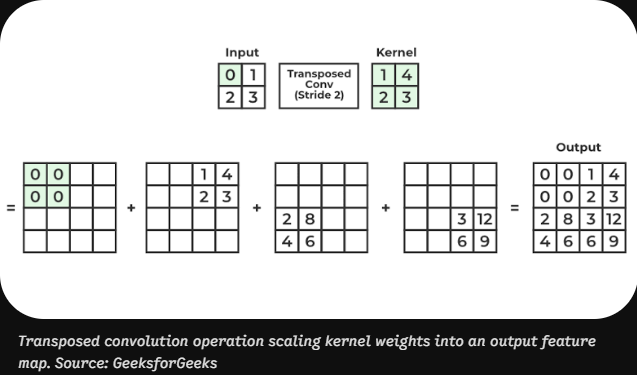

### Example

Suppose you have:
- **Input dimensions**: 2x2
- **Kernel size**: 3x3
- **Stride**: 2
- **Padding**: 0
- **Output padding**: 0

The output dimensions will be:

$$
H_{\text{out}} = (2 - 1) \times 2 - 2 \times 0 + 3 + 0 = 5
$$
$$
W_{\text{out}} = (2 - 1) \times 2 - 2 \times 0 + 3 + 0 = 5
$$

So, the output will be a 5x5 feature map.

### Padding vs. Output Padding

The two parameters have different effects in the formula: **padding subtracts $2p$**, while **output padding adds $o$**. Padding affects both sides of each spatial dimension; output padding typically extends the bottom/right boundary.

Keeping the example's **2x2 input, 3x3 kernel, and stride 2**, we get:

| Padding | Output padding | Calculation for each dimension | Output size |
|---|---|---|---|
| 0 | 0 | $(2 - 1) \times 2 - 2 \times 0 + 3 + 0 = 5$ | 5x5 |
| 1 | 0 | $(2 - 1) \times 2 - 2 \times 1 + 3 + 0 = 3$ | 3x3 |
| 1 | 1 | $(2 - 1) \times 2 - 2 \times 1 + 3 + 1 = 4$ | 4x4 |

**Why is output padding needed?** A regular convolution with kernel size 3, stride 2, and padding 1 maps **both a 3x3 input and a 4x4 input to a 2x2 output**. The smaller feature map alone does not tell us which original spatial size to choose.

A transposed convolution with the same kernel size, stride, and padding therefore uses **output padding 0 to select 3x3**, or **output padding 1 to select 4x4**. This resolves the output-size ambiguity; it does **not** recover the original input values or simply append a border of zeros.

### Difference from Regular Convolution

- **Convolution**: Reduces spatial dimensions (downsampling).
- **Transposed Convolution**: Increases spatial dimensions (upsampling).

### Valid vs. Same Transposed Convolutions

- **Same Transposed Convolution**: Produces an output of the same size as the input when strides and padding are chosen appropriately.
- **Valid Transposed Convolution**: No padding is added, so the output size strictly depends on the kernel size and stride.

### Use Cases of Transposed Convolutions

1. **Autoencoders**: To reconstruct an input image from a compressed latent space.
2. **Generative Adversarial Networks (GANs)**: To generate high-resolution images from a low-dimensional latent space.
3. **Segmentation Tasks**: To map back from feature maps to full-resolution segmentation masks.

### Summary

- **Transposed Convolution**: A learnable operation used for upsampling.
- **Output Dimensions**: Depend on stride, kernel size, padding, and optional output padding.
- **Applications**: Used in tasks requiring upsampling, like image reconstruction, generation, or segmentation.

This operation allows CNNs to learn the best way to upscale feature maps during tasks that require increasing spatial dimensions.

---

## Upsampling with Bilinear Interpolation <a id="bilinear_interpolation"></a>

**Bilinear interpolation** enlarges an image or feature map by calculating new values from nearby input values. It uses a fixed weighted-average rule, with **no learned weights**.

### Example: (1, 3, 4, 4) to (1, 3, 8, 8)

The shape is written as **(batch size, channels, height, width)**. Here we have one image with three channels, each containing a 4x4 grid. Upsampling by a factor of 2 doubles the height and width of each channel independently:

```text
              Input          Output
Channel 1     4x4 grid   ->   8x8 grid
Channel 2     4x4 grid   ->   8x8 grid
Channel 3     4x4 grid   ->   8x8 grid

Shape: (1, 3, 4, 4) -> (1, 3, 8, 8)
```

**The batch size and channel count stay the same.** Values from different channels are never mixed.

### How are the new values calculated?

For each output position:

1. Map its location back to the input grid. This location may fall between input pixels.
2. Find the four surrounding input values in the same channel.
3. Interpolate horizontally, then vertically, to get a weighted average. Closer values contribute more. At the image boundary, edge values are used as needed.

For example, suppose the four surrounding values are:

```text
10 ----- 20
 |       |
 |   ?   |
 |       |
30 ----- 40
```

At the exact center, all four values have equal weight, so the interpolated value is **(10 + 20 + 30 + 40) / 4 = 25**. A location closer to the top-left corner gives more weight to 10. This illustrates the averaging rule; the exact sampled locations depend on how the input and output grids are aligned.

Repeat this process for all 64 positions in each 8x8 output channel. Each channel grows from 16 values to 64 values, while the number of channels remains three.

### Difference from Transposed Convolution

| Bilinear interpolation | Transposed convolution |
|---|---|
| Uses a fixed interpolation rule | Uses learned kernel weights |
| Resizes each channel independently and preserves channel count | Can mix channels and change channel count |
| Produces a smooth resize based on nearby values | Learns how to upsample for the task |

A common approach is **bilinear upsampling followed by a regular convolution**: interpolation enlarges the spatial dimensions, and the convolution learns how to refine the features and mix channels.
